**Image Generation with Variational Autoencoders**

In [11]:
import torch
import torch.nn.functional as F
from torch import nn
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

In [4]:
transform = T.Compose([
            T.Resize(256),
            T.ToTensor(),
            ])
data = torchvision.datasets.ImageFolder(
    root=r"D:\DeepLearning\DataSet\Figure\glass\glasses",
    transform=transform)
batch_size=16
loader = torch.utils.data.DataLoader(data,
     batch_size=batch_size,shuffle=True)

In [5]:
latent_dims=100
class Encoder(nn.Module):
    def __init__(self, latent_dims=100):  
        super().__init__()
        # input 256 by 256 by 3 channels
        self.conv1 = nn.Conv2d(3, 8, 3, stride=2, padding=1)
        # 128 by 128 with 8 channels
        self.conv2 = nn.Conv2d(8, 16, 3, stride=2, padding=1)
        # 64 by 64 with 16 channels
        self.batch2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 32, 3, stride=2, padding=0)  
        # 31 by 31 with 32 channels
        self.linear1 = nn.Linear(31*31*32, 1024)
        self.linear2 = nn.Linear(1024, latent_dims)
        self.linear3 = nn.Linear(1024, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.cuda() 
        self.N.scale = self.N.scale.cuda()

    def forward(self, x):
        x = x.to(device)
        x = F.relu(self.conv1(x))
        x = F.relu(self.batch2(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu =  self.linear2(x)
        std = torch.exp(self.linear3(x))
        z = mu + std*self.N.sample(mu.shape)
        return mu, std, z  

In [6]:
class Decoder(nn.Module):   
    def __init__(self, latent_dims=100):
        super().__init__()
        self.decoder_lin = nn.Sequential(
            nn.Linear(latent_dims, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 31*31*32),
            nn.ReLU(True))
        self.unflatten = nn.Unflatten(dim=1, 
                  unflattened_size=(32,31,31))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32,16,3,stride=2,
                               output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, 
                               padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 3, 3, stride=2,
                               padding=1, output_padding=1))
        
    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x  

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dims=100):
        super().__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)
    def forward(self, x):
        x = x.to(device)
        mu, std, z = self.encoder(x)
        return mu, std, self.decoder(z) 

In [9]:
device="cuda" if torch.cuda.is_available() else "cpu"

vae=VAE().to(device)
lr=1e-4 
optimizer=torch.optim.Adam(vae.parameters(),
                           lr=lr,weight_decay=1e-5)

Train the Variational Autoencoder

In [10]:
def train_epoch(epoch):
    vae.train()
    epoch_loss = 0.0
    for imgs, _ in loader: 
        imgs = imgs.to(device)
        mu, std, out = vae(imgs)
        # reconstruction loss
        reconstruction_loss = ((imgs-out)**2).sum() 
        # kl loss
        kl = ((std**2)/2 + (mu**2)/2 - torch.log(std) - 0.5).sum()
        # total loss
        loss = reconstruction_loss + kl
        # Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        epoch_loss+=loss.item()
    print(f'at epoch {epoch}, loss is {epoch_loss}')  

In [12]:
def plot_epoch():
    with torch.no_grad():
        noise = torch.randn(18,latent_dims).to(device)
        imgs = vae.decoder(noise).cpu()
        imgs = torchvision.utils.make_grid(imgs,6,3).numpy()
        fig, ax = plt.subplots(figsize=(6,3),dpi=100)
        plt.imshow(np.transpose(imgs, (1, 2, 0)))
        plt.axis("off")
        plt.show()      

at epoch 0, loss is 38220558.5625
epoch:  0


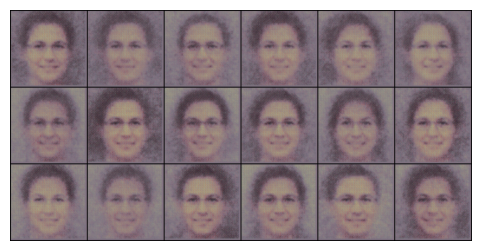

at epoch 1, loss is 24030424.6015625
at epoch 2, loss is 17239004.666992188
at epoch 3, loss is 13424284.204101562
at epoch 4, loss is 11211469.913085938


KeyboardInterrupt: 

In [14]:
for epoch in range(101):
    train_epoch(epoch)
    if(epoch%10==0):
        plot_epoch()
torch.save(vae.state_dict(),"results/VAEglasses.pth")    

Generate Images with the Trained Model

In [15]:
vae.eval()
vae.load_state_dict(torch.load(r"D:\DeepLearning\DataSet\Model-Weight\VAE\VAEglasses.pth",
                              map_location=device))

<All keys matched successfully>

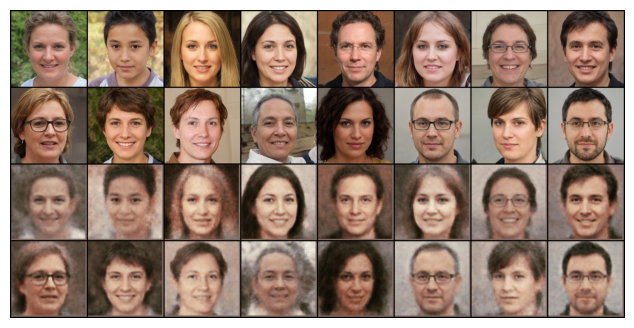

In [16]:
# compare original with reconstructed
imgs,_=next(iter(loader))
imgs = imgs.to(device)
mu, std, out = vae(imgs)
images=torch.cat([imgs,out],dim=0).detach().cpu()
images = torchvision.utils.make_grid(images,8,4)
fig, ax = plt.subplots(figsize=(8,4),dpi=100)
plt.imshow(np.transpose(images, (1, 2, 0)))
plt.axis("off")
plt.show()      

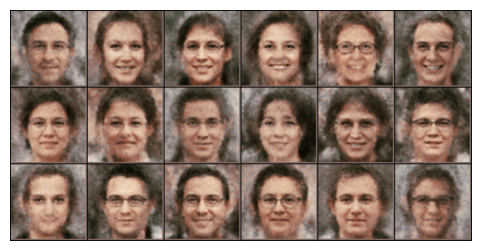

In [18]:
plot_epoch()  

Encoding Arithmetic with the Trained VAE

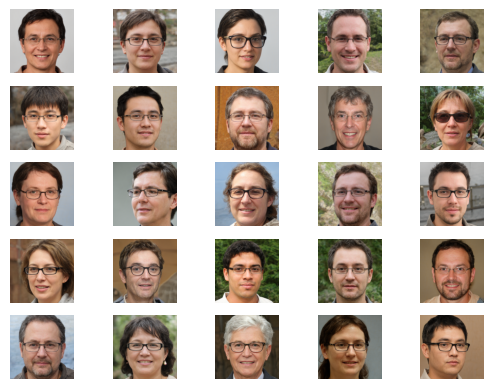

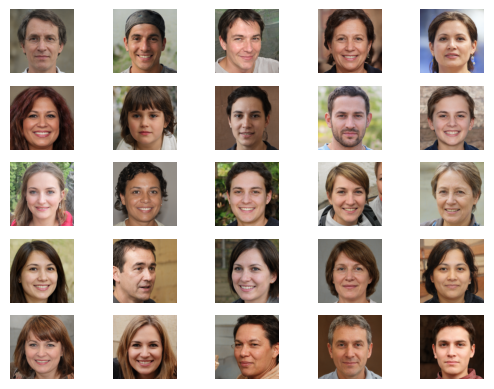

In [19]:
torch.manual_seed(0)  # make sure you fix the random state
glasses=[]
for i in range(25):
    img,label=data[i]
    glasses.append(img)
    plt.subplot(5,5,i+1)
    plt.imshow(img.numpy().transpose((1,2,0)))
    plt.axis("off")
plt.show()
# select three men's images    
men_g=[glasses[0],glasses[3],glasses[14]]
# select three women's images    
women_g=[glasses[9],glasses[15],glasses[21]] 

# collect 25 five images without glasses
noglasses=[]
for i in range(25):
    img,label=data[-i-1]
    noglasses.append(img)
    plt.subplot(5,5,i+1)
    plt.imshow(img.numpy().transpose((1,2,0)))
    plt.axis("off")
plt.show()
# select three men's images    
men_ng=[noglasses[1],noglasses[7],noglasses[22]]
# select three women's images    
women_ng=[noglasses[4],noglasses[9],noglasses[19]]

In [20]:
# create a batch of images of men with glasses
men_g_batch = torch.cat((men_g[0].unsqueeze(0),    #A
             men_g[1].unsqueeze(0),
             men_g[2].unsqueeze(0)), dim=0).to(device)
# Obtain the three encodings
_,_,men_g_encodings=vae.encoder(men_g_batch)
# Average over the three images to obtain the encoding for the group
men_g_encoding=men_g_encodings.mean(dim=0)    #B
# Decode the average encoding to create an image of a man with glasses 
men_g_recon=vae.decoder(men_g_encoding.unsqueeze(0))    #C

# Do the same for the other three groups
# group 2, women with glasses
women_g_batch = torch.cat((women_g[0].unsqueeze(0),
             women_g[1].unsqueeze(0),
             women_g[2].unsqueeze(0)), dim=0).to(device)
# group 3, men without glasses
men_ng_batch = torch.cat((men_ng[0].unsqueeze(0),
             men_ng[1].unsqueeze(0),
             men_ng[2].unsqueeze(0)), dim=0).to(device)
# group 4, women without glasses
women_ng_batch = torch.cat((women_ng[0].unsqueeze(0),
             women_ng[1].unsqueeze(0),
             women_ng[2].unsqueeze(0)), dim=0).to(device)
# obtain average encoding for each group
_,_,women_g_encodings=vae.encoder(women_g_batch)
women_g_encoding=women_g_encodings.mean(dim=0)
_,_,men_ng_encodings=vae.encoder(men_ng_batch)
men_ng_encoding=men_ng_encodings.mean(dim=0)
_,_,women_ng_encodings=vae.encoder(women_ng_batch)
women_ng_encoding=women_ng_encodings.mean(dim=0)    #D
# decode for each group
women_g_recon=vae.decoder(women_g_encoding.unsqueeze(0))
men_ng_recon=vae.decoder(men_ng_encoding.unsqueeze(0))
women_ng_recon=vae.decoder(women_ng_encoding.unsqueeze(0))    #E

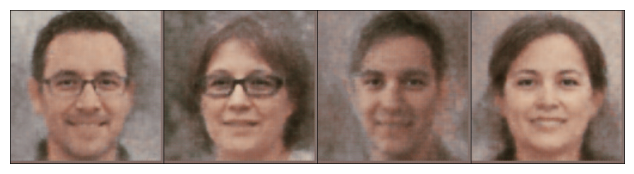

In [21]:
imgs=torch.cat((men_g_recon,
                women_g_recon,
                men_ng_recon,
                women_ng_recon),dim=0)
imgs=torchvision.utils.make_grid(imgs,4,1).cpu().numpy()
imgs=np.transpose(imgs,(1,2,0))
fig, ax = plt.subplots(figsize=(8,2),dpi=100)
plt.imshow(imgs)
plt.axis("off")
plt.show()

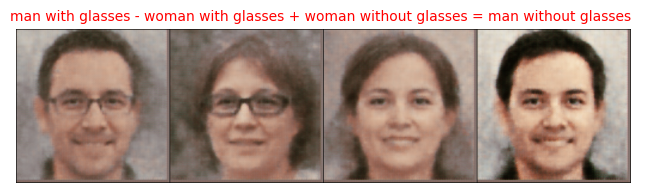

In [22]:
z=men_g_encoding-women_g_encoding+women_ng_encoding
out=vae.decoder(z.unsqueeze(0))
imgs=torch.cat((men_g_recon,
                women_g_recon,
                women_ng_recon,out),dim=0)
imgs=torchvision.utils.make_grid(imgs,4,1).cpu().numpy()
imgs=np.transpose(imgs,(1,2,0))
fig, ax = plt.subplots(figsize=(8,2),dpi=100)
plt.imshow(imgs)
plt.title("man with glasses - woman \
with glasses + woman without \
glasses = man without glasses ",fontsize=10,c="r")
plt.axis("off")
plt.show()

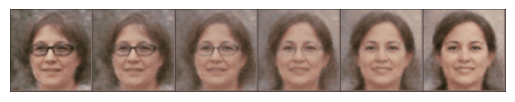

In [23]:
# woman with glasses to woman without glasses
results=[]
for w in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    z=w*women_ng_encoding+(1-w)*women_g_encoding
    out=vae.decoder(z.unsqueeze(0))
    results.append(out)
imgs=torch.cat((results[0],results[1],results[2],
                results[3],results[4],results[5]),dim=0)
imgs=torchvision.utils.make_grid(imgs,6,1).cpu().numpy()
imgs=np.transpose(imgs,(1,2,0))
fig, ax = plt.subplots(dpi=100)
plt.imshow(imgs)
plt.axis("off")
plt.show() 